# DP spectral atlas — is every error type spectrally distinct from true on A′(β, α)?

**Purpose (supervisor programme points 2+3, George 2026-07-06).** The Bifurification pilot
showed the ε-windowed fork works classically but the 1BQF single notch misses the shifted
spectrum, and the occupancy term is counterproductive for the 1BQF. Before any quantum re-run,
this notebook builds the **per-error-type spectral atlas** of the DP-modified Hamiltonian:
for every cluster family (true P4, true fragments, isolated false, false pairs/chains, hubs,
contaminated) it measures *where the family's solution weight sits spectrally* under
A′(β, α) = A0 + β·B_fork(ε_B=ε) + 4αI + 2α·B_all — and whether a comb can pass true and
zero each false family **without re-admitting another** (the shared-line obstruction).

Classical-first per George 2026-07-04: exact per-cluster eigendecomposition + truth overlap;
the comb/1BQF are applied as *responses on the eigenvalues* (no circuits).

| parameter | value |
|---|---|
| noise | σ_scatt = 1e-4 · σ_res = 10 µm · drop = 1 % · φ_max = 0.2 (DP pilot point) |
| window | formula ε = 3.178 mrad · step kernel · γ = 3, δ = 1 (s = 4) |
| events | T ∈ {100, 200} × reps {0, 1, 2} (qtrk store) |
| fork | β ∈ {0, 0.5, 1}, ε_B = ε |
| occupancy | α ∈ {0.1, 0.3} (Lanczos family measures — B_all merges clusters) |
| comb | production line comb: P4 lines s−2cos(kπ/5), hw = 0.18, degree = max(40, 2W/0.30) ≤ 127, Gershgorin domain |

Provenance: `Bifurification/dp_terms.py` (A′ composition) · `dp_classical_spectrum.csv` (global measures)
· taxonomy per `QSVT/Segment_level_studies/07_perfecting_the_comb.ipynb` · this notebook = per-family resolution.


In [1]:
import sys, time, collections, gzip
from pathlib import Path
for p in ("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared",
          "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src",
          "/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Bifurification"):
    if p not in sys.path: sys.path.insert(0, p)
import numpy as np, pandas as pd, scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
from scipy.linalg import eigh, eigh_tridiagonal
import matplotlib.pyplot as plt
import qtrk_pipeline as qp
import dp_terms
from lhcb_velo_toy.analysis import compute_epsilon
from lhcb_velo_toy.solvers.quantum import design_line_comb_inverse
plt.rcParams.update({"figure.dpi":115,"font.size":10,"axes.grid":True,"grid.alpha":0.3})

NOISE = dict(sigma_scatt=1e-4, sigma_res=0.01, phi_max=0.2, hit_ineff=0.01)
GAMMA, DELTA = 3.0, 1.0; S = GAMMA + DELTA
EPS  = float(compute_epsilon(NOISE["sigma_res"], NOISE["sigma_scatt"]))
P4   = S - 2*np.cos(np.arange(1,5)*np.pi/5)
HW   = 0.18
TS, REPS, BETAS, ALPHAS = [100, 200], [0, 1, 2], [0.0, 0.5, 1.0], [0.1, 0.3]
TAU_FIX = qp.threshold_for(GAMMA, DELTA)     # 0.35 (fork keeps the attractor)
OUT = Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Codesign/outputs/dp_atlas")
OUT.mkdir(parents=True, exist_ok=True)
def savefig(fig, name):
    for e, dp in (("pdf", 600), ("png", 300)):
        fig.savefig(OUT/f"{name}.{e}", dpi=dp, bbox_inches="tight", facecolor="white")

HAMS = {}
def get_ham(T, rep):
    k = (T, rep)
    if k not in HAMS:
        ev, _ = qp.ensure_event(n_trk=T, rep=rep, **NOISE)
        ham = qp.build_hamiltonian(ev, epsilon=EPS, kernel="step", gamma=GAMMA, delta=DELTA)
        HAMS[k] = (ham, np.asarray(qp.truth_from_event(ev), bool))
    return HAMS[k]
print(f"setup ok | eps = {EPS*1e3:.3f} mrad | tau_fix = {TAU_FIX} | P4 lines {np.round(P4,4)}")


setup ok | eps = 3.178 mrad | tau_fix = 0.35 | P4 lines [2.382 3.382 4.618 5.618]


## 1. Taxonomy

Base families are classified on the **β = 0 coupling graph** (off-diagonal of A0) by shape +
truth content: `true P4` · `true fragment (P1–P3)` (drop-induced) · `true long-chain` ·
`isolated false` · `false pair P2` · `false chain P3+` (bridges) · `false hub K(1,m)` ·
`false tangle` · `contaminated (true+false)`. Under β > 0 the fork **adds edges → clusters
merge**; each A′ component is re-labelled: any true content → `contaminated (true+false)`
unless all-true; all-false components take the majority base family of their members.
Every eigenmode row records λ, solution weight w ∝ (uᵀb/λ)², truth projection ρ = Σ_true u².


In [2]:
def offdiag_graph(A):
    G = sp.csr_matrix(A, copy=True); G.setdiag(0); G.eliminate_zeros()
    return (abs(G) > 1e-12).astype(np.int8)

def base_label(members, truth, G):
    m, nt = len(members), int(truth[members].sum())
    if m == 1: return "true fragment (P1-P3)" if nt else "isolated false"
    deg = np.asarray(G[members][:, members].sum(axis=1)).ravel()
    sd = sorted(deg.tolist())
    is_path = sd == [1, 1] + [2]*(m-2)
    is_star = m >= 3 and sd == [1]*(m-1) + [m-1]
    if nt == m:
        if is_path: return "true P4" if m == 4 else ("true fragment (P1-P3)" if m < 4 else "true long-chain")
        return "true long-chain"  # all-true non-path (vertex-sharing trues): rare
    if nt == 0:
        if is_path: return "false pair P2" if m == 2 else "false chain P3+"
        if is_star: return "false hub K(1,m)"
        return "false tangle"
    return "contaminated (true+false)"

def merged_label(members, truth, seg_base):
    nt = int(truth[members].sum())
    if 0 < nt < len(members): return "contaminated (true+false)"
    if nt == len(members):
        labs = collections.Counter(seg_base[members]);  return labs.most_common(1)[0][0]
    labs = collections.Counter(seg_base[members]);  return labs.most_common(1)[0][0]

def components_of(A):
    n, lab = connected_components(offdiag_graph(A), directed=False)
    order = np.argsort(lab, kind="stable")
    bounds = np.searchsorted(lab[order], np.arange(n))
    return n, lab, order, np.append(bounds, len(lab))

def gershgorin(A):
    A = sp.csr_matrix(A); d = A.diagonal()
    R = np.asarray(abs(A).sum(axis=1)).ravel() - abs(d)
    return float((d - R).min()), float((d + R).max())
print("taxonomy helpers ok")


taxonomy helpers ok


In [3]:
# ---- 2. The fork atlas: per-cluster exact eigh on A'(beta), all events ----
FAMS = ["true P4","true fragment (P1-P3)","true long-chain","contaminated (true+false)",
        "isolated false","false pair P2","false chain P3+","false hub K(1,m)","false tangle"]
rows, SOLS, TRUTHS, DOMS = [], {}, {}, {}
t0 = time.time()
for T in TS:
    for rep in REPS:
        ham, truth = get_ham(T, rep); TRUTHS[(T, rep)] = truth
        n = ham.n_segments
        A0 = ham.A.tocsr()
        nb0, lab0, o0, b0 = components_of(A0)
        seg_base = np.empty(n, dtype=object)
        G0 = offdiag_graph(A0)
        for c in range(nb0):
            mem = o0[b0[c]:b0[c+1]]
            seg_base[mem] = base_label(mem, truth, G0)
        for beta in BETAS:
            Ab, bvec, tau_b, info = dp_terms.dp_system(ham, beta=beta, eps_B=EPS,
                                                       gamma=GAMMA, delta=DELTA)
            Ab = Ab.tocsr()
            lo, hi = gershgorin(Ab); DOMS[(T, rep, beta)] = (lo, hi)
            nbc, lab, order, bnd = components_of(Ab)
            xC = np.zeros(n); xQ = np.zeros(n); xP = np.zeros(n); xE = np.zeros(n)
            # comb response for THIS spectrum footprint (Gershgorin domain, resolution-scaled degree)
            W = 0.5*(hi - lo); margin = 0.05*(hi - lo) + 0.2
            dom = (lo - margin, hi + margin)
            deg = int(min(127, max(40, np.ceil(2*W/0.30))))
            pC = design_line_comb_inverse(degree=deg, s=S, hw=HW, domain=dom)
            LEXT = np.concatenate([P4, [S-np.sqrt(2), S+np.sqrt(2), S-1.0, S+1.0]])
            pE = design_line_comb_inverse(degree=max(60, deg), s=S, lines=LEXT, hw=HW, domain=dom)
            t1BQF = np.pi/S
            maxsz = 0
            for c in range(nbc):
                mem = order[bnd[c]:bnd[c+1]]; m = len(mem); maxsz = max(maxsz, m)
                fam = merged_label(mem, truth, seg_base)
                nfork = 0
                if m == 1:
                    lam = float(Ab[mem[0], mem[0]]); u = np.ones(1); w = (1.0/lam)**2
                    rows.append((T, rep, beta, c, fam, m, 0, lam, w, float(truth[mem[0]])))
                    xC[mem] += 1.0/lam; xQ[mem] += np.cos(lam*t1BQF/2.0); xP[mem] += pC(lam); xE[mem] += pE(lam)
                    continue
                sub = Ab[mem][:, mem].toarray()
                wl, U = eigh(sub)
                bk = U.T @ np.ones(m)
                rho = (U[truth[mem]]**2).sum(axis=0) if truth[mem].any() else np.zeros(m)
                for k in range(m):
                    if abs(bk[k]) < 1e-12: continue
                    rows.append((T, rep, beta, c, fam, m, info["Bfork_nnz"], float(wl[k]),
                                 float((bk[k]/wl[k])**2), float(rho[k])))
                xC[mem] += U @ (bk/wl)
                xQ[mem] += U @ (bk*np.cos(wl*t1BQF/2.0))
                xP[mem] += U @ (bk*pC(wl))
                xE[mem] += U @ (bk*pE(wl))
            SOLS[(T, rep, beta)] = dict(classical=xC, onebqf=xQ, comb=xP, ext=xE, deg=deg, dom=dom)
            print(f"T={T} rep={rep} beta={beta:g}: comps={nbc} maxsz={maxsz} "
                  f"Gershgorin=[{lo:.2f},{hi:.2f}] deg={deg}  ({time.time()-t0:.0f}s)", flush=True)
ATLAS = pd.DataFrame(rows, columns=["T","rep","beta","cid","family","size","fork_nnz",
                                    "lam","w_sol","rho_true"])
ATLAS.to_csv(OUT/"atlas_modes.csv.gz", index=False)
print("atlas rows:", len(ATLAS))


T=100 rep=0 beta=0: comps=39480 maxsz=4 Gershgorin=[2.00,6.00] deg=40  (6s)


T=100 rep=0 beta=0.5: comps=39480 maxsz=4 Gershgorin=[2.00,6.00] deg=40  (11s)


T=100 rep=0 beta=1: comps=39480 maxsz=4 Gershgorin=[2.00,6.00] deg=40  (16s)


T=100 rep=1 beta=0: comps=39481 maxsz=5 Gershgorin=[1.00,7.00] deg=40  (22s)


T=100 rep=1 beta=0.5: comps=39217 maxsz=5 Gershgorin=[1.00,7.00] deg=40  (28s)


...

T=200 rep=1 beta=1: comps=152484 maxsz=14 Gershgorin=[0.00,8.00] deg=40  (184s)


T=200 rep=2 beta=0: comps=157830 maxsz=6 Gershgorin=[1.00,7.00] deg=40  (206s)


T=200 rep=2 beta=0.5: comps=155859 maxsz=12 Gershgorin=[0.50,7.50] deg=40  (228s)


T=200 rep=2 beta=1: comps=155859 maxsz=12 Gershgorin=[0.00,8.00] deg=40  (250s)


atlas rows: 1747790


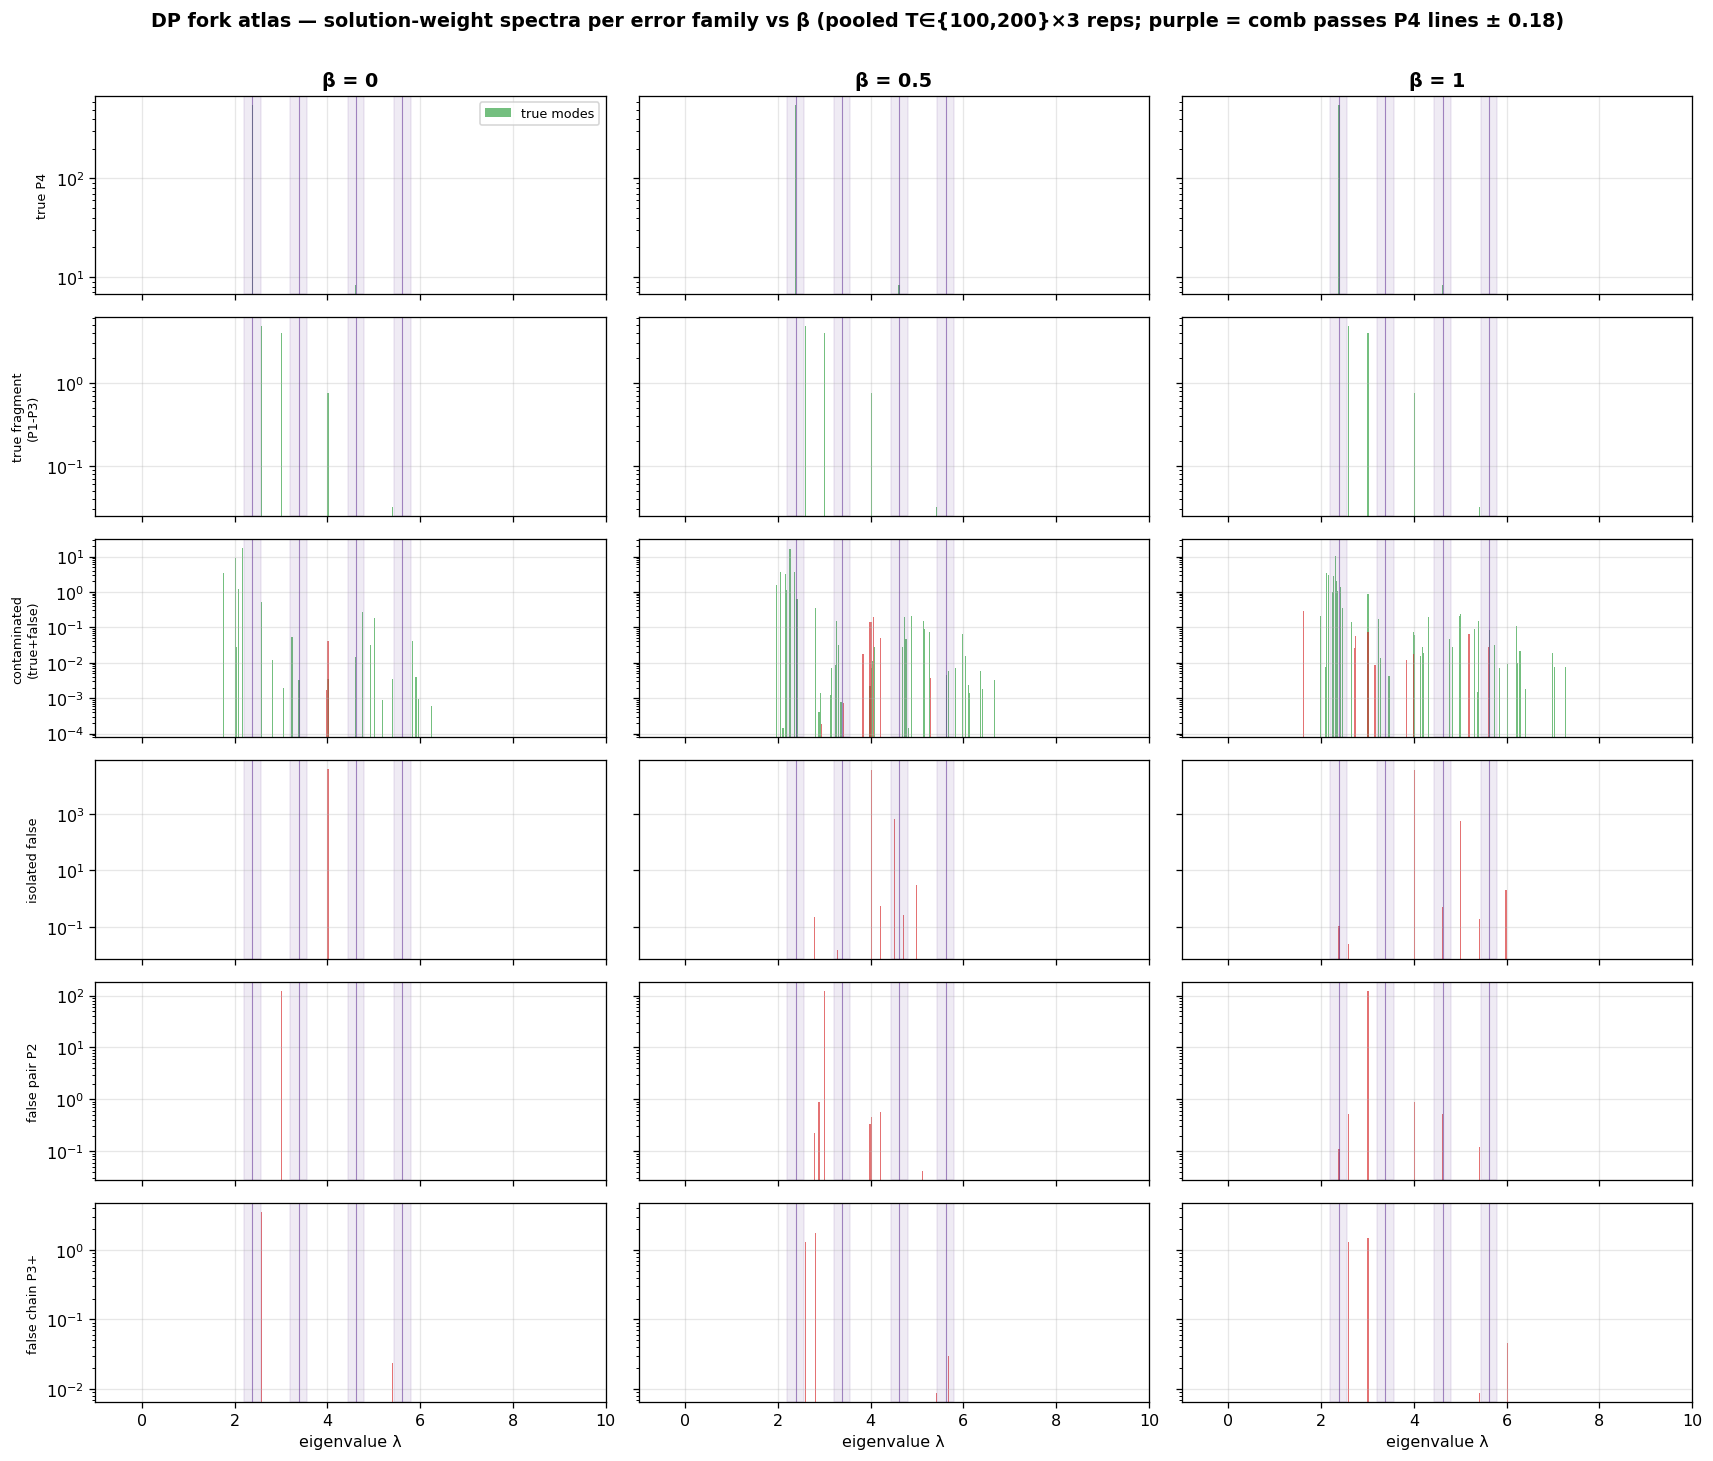

In [4]:
# ---- 3. The atlas figure: per-family solution-weight spectra vs beta ----
SHOW = [f for f in FAMS if f in set(ATLAS.family) and f != "true long-chain"]
grid = np.linspace(-0.5, 9.5, 401)
fig, ax = plt.subplots(len(SHOW), len(BETAS), figsize=(15, 2.1*len(SHOW)),
                       sharex=True, sharey="row")
for i, fam in enumerate(SHOW):
    for j, beta in enumerate(BETAS):
        a = ax[i, j]
        d = ATLAS[(ATLAS.family == fam) & (ATLAS.beta == beta)]
        for sel, col, lab in ((d.rho_true >= 0.5, "#2a9d3a", "true modes"),
                              (d.rho_true < 0.5, "#d62728", "false modes")):
            dd = d[sel]
            if len(dd):
                a.hist(dd.lam, bins=grid, weights=dd.w_sol, color=col, alpha=0.65, label=lab)
        for L in P4:
            a.axvspan(L-HW, L+HW, color="#6a3d9a", alpha=0.10)
            a.axvline(L, color="#6a3d9a", lw=0.7, alpha=0.6)
        a.set_yscale("log")
        if i == 0: a.set_title(f"β = {beta:g}", fontweight="bold")
        if j == 0: a.set_ylabel(fam.replace(" (", chr(10)+"("), fontsize=8)
        if i == len(SHOW)-1: a.set_xlabel("eigenvalue λ")
ax[0, 0].legend(fontsize=8)
fig.suptitle("DP fork atlas — solution-weight spectra per error family vs β "
             f"(pooled T∈{{100,200}}×3 reps; purple = comb passes P4 lines ± {HW})",
             fontweight="bold", y=1.005)
fig.tight_layout()
savefig(fig, "dp_atlas_fork_spectra"); plt.show()


TRUE-mode weight captured by the comb bands (want -> 1 for true rows):
beta                         0.0    0.5    1.0
family                                        
true P4                    100.0  100.0  100.0
true fragment (P1-P3)        0.0    0.0    0.0
contaminated (true+false)    1.1   66.8   68.7
isolated false               NaN    NaN    NaN
false pair P2                NaN    NaN    NaN
false chain P3+              NaN    NaN    NaN

FALSE-mode weight inside the comb bands = re-admitted (want -> 0):
beta                       0.0  0.5  1.0
family                                  
true P4                    NaN  NaN  NaN
true fragment (P1-P3)      NaN  NaN  NaN
contaminated (true+false)  0.0  0.1  4.7
isolated false             0.0  1.8  0.0
false pair P2              0.0  0.0  0.5
false chain P3+            0.0  1.0  0.0


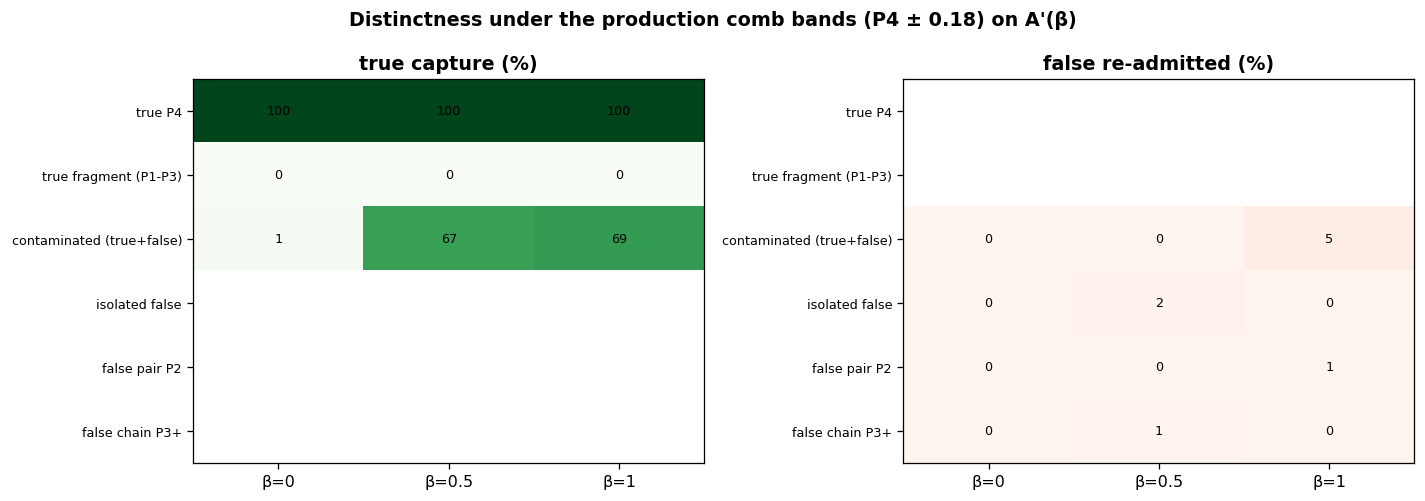

In [5]:
# ---- 4. Distinctness: per family, what fraction of solution weight the comb passes ----
def in_bands(lam):
    return (np.abs(lam[:, None] - P4[None, :]) <= HW).any(axis=1)
rec = []
for (fam, beta), d in ATLAS.groupby(["family", "beta"]):
    tm, fm = d[d.rho_true >= 0.5], d[d.rho_true < 0.5]
    r = dict(family=fam, beta=beta,
             true_capture=float(tm.w_sol[in_bands(tm.lam.values)].sum()/max(tm.w_sol.sum(),1e-30)) if len(tm) else np.nan,
             false_leak=float(fm.w_sol[in_bands(fm.lam.values)].sum()/max(fm.w_sol.sum(),1e-30)) if len(fm) else np.nan,
             w_true=float(tm.w_sol.sum()), w_false=float(fm.w_sol.sum()),
             min_dist=float(np.abs(fm.lam.values[:, None]-P4[None, :]).min()) if len(fm) else np.nan)
    rec.append(r)
DIST = pd.DataFrame(rec)
DIST.to_csv(OUT/"distinctness.csv", index=False)
piv_c = DIST.pivot(index="family", columns="beta", values="true_capture").reindex(SHOW)
piv_l = DIST.pivot(index="family", columns="beta", values="false_leak").reindex(SHOW)
print("TRUE-mode weight captured by the comb bands (want -> 1 for true rows):")
print((100*piv_c).round(1).to_string())
print(chr(10)+"FALSE-mode weight inside the comb bands = re-admitted (want -> 0):")
print((100*piv_l).round(1).to_string())
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
for a, piv, ttl, cm in ((ax[0], piv_c, "true capture (%)", "Greens"),
                        (ax[1], piv_l, "false re-admitted (%)", "Reds")):
    im = a.imshow(100*piv.values, aspect="auto", cmap=cm, vmin=0, vmax=100)
    a.set_xticks(range(len(BETAS)), [f"β={b:g}" for b in BETAS])
    a.set_yticks(range(len(piv)), piv.index, fontsize=8)
    for ii in range(piv.shape[0]):
        for jj in range(piv.shape[1]):
            v = 100*piv.values[ii, jj]
            if np.isfinite(v): a.text(jj, ii, f"{v:.0f}", ha="center", va="center", fontsize=8)
    a.set_title(ttl, fontweight="bold"); a.grid(False)
fig.suptitle("Distinctness under the production comb bands (P4 ± 0.18) on A'(β)", fontweight="bold")
fig.tight_layout(); savefig(fig, "dp_atlas_distinctness"); plt.show()


## 5. Classical efficacy — response-on-A′ shoot-out and the zeroing table

Responses applied exactly on the stored eigenpairs (x_f = Σ u_k β_k f(λ_k)): **classical 1/λ**,
**1BQF cos(λt/2), t = π/s** (the emulation the pilot showed breaking), and the **production
comb** (domain Gershgorin-sized, degree 2W/0.30-scaled). Quantum-convention responses are
signal-rescaled against the classical partner *on the same A′*. Reported: eff/far at fixed
attractor τ = 0.35 and at the per-solver wp99, plus the **per-family median activation** —
George's "each error type zeroed?" table.


mean over T x reps (fixed tau=0.35 | wp99):
                eff_fix  far_fix  eff_wp  far_wp
solver    beta                                  
classical 0.0     98.76     1.56   99.75   24.23
          0.5     97.98     0.52   99.58   28.18
          1.0     97.98     0.49   99.39   28.16
comb      0.0     94.92     0.00   99.68   66.25
          0.5     95.85     0.00   99.79   75.77
          1.0     95.49     0.00   99.66   50.05
onebqf    0.0     49.26     0.43   99.75   31.79
          0.5     49.24     0.43   99.53   59.47
          1.0     49.24     3.74   99.51   67.81


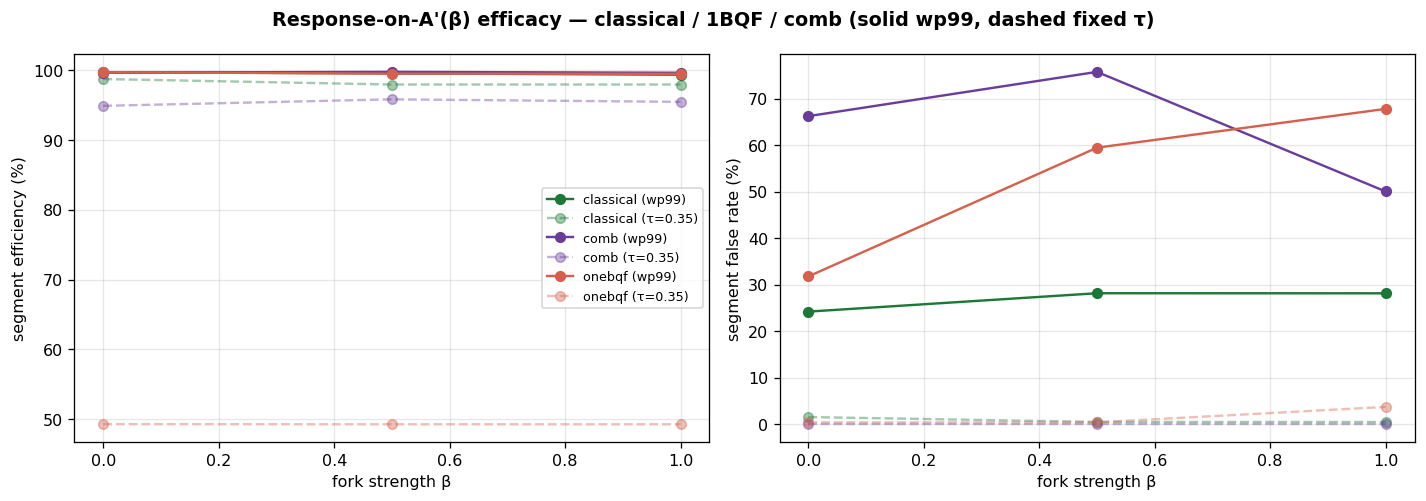

In [6]:
def wp99(sol, truth):
    st = np.sort(sol[truth]); tau = st[int(np.floor(0.01*len(st)))] - 1e-9
    act = sol > tau
    return tau, float((act & truth).sum()/truth.sum()), float((act & ~truth).sum()/max(act.sum(),1))
met = []
for (T, rep, beta), sols in SOLS.items():
    truth = TRUTHS[(T, rep)]; xC = np.abs(sols["classical"])
    for name in ("classical", "onebqf", "comb"):
        x = np.abs(sols[name])
        if name != "classical": x = qp.rescale_to_signal(x, xC, TAU_FIX)
        act = x > TAU_FIX
        tau_w, eff_w, far_w = wp99(x, truth)
        met.append(dict(T=T, rep=rep, beta=beta, solver=name, deg=sols["deg"],
                        eff_fix=float((act & truth).sum()/truth.sum()),
                        far_fix=float((act & ~truth).sum()/max(act.sum(),1)),
                        eff_wp=eff_w, far_wp=far_w, tau_wp=tau_w))
MET = pd.DataFrame(met)
MET.to_csv(OUT/"efficacy_metrics.csv", index=False)
agg = MET.groupby(["solver","beta"])[["eff_fix","far_fix","eff_wp","far_wp"]].mean()
print("mean over T x reps (fixed tau=0.35 | wp99):"); print((100*agg).round(2).to_string())
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4), sharex=True)
cols = dict(classical="#1b7837", onebqf="#d6604d", comb="#6a3d9a")
for name, g in MET.groupby("solver"):
    gm = g.groupby("beta").mean(numeric_only=True)
    ax[0].plot(gm.index, 100*gm.eff_wp, "o-", color=cols[name], label=f"{name} (wp99)")
    ax[0].plot(gm.index, 100*gm.eff_fix, "o--", color=cols[name], alpha=0.4, label=f"{name} (τ=0.35)")
    ax[1].plot(gm.index, 100*gm.far_wp, "o-", color=cols[name])
    ax[1].plot(gm.index, 100*gm.far_fix, "o--", color=cols[name], alpha=0.4)
ax[0].set_ylabel("segment efficiency (%)"); ax[1].set_ylabel("segment false rate (%)")
for a in ax: a.set_xlabel("fork strength β")
ax[0].legend(fontsize=8)
fig.suptitle("Response-on-A'(β) efficacy — classical / 1BQF / comb (solid wp99, dashed fixed τ)",
             fontweight="bold")
fig.tight_layout(); savefig(fig, "dp_atlas_efficacy"); plt.show()


In [7]:
# ---- 6. The zeroing table: per-family median activation per response (T=200) ----
zt = []
for rep in REPS:
    ham, truth = get_ham(200, rep)
    n = ham.n_segments
    segfam = np.empty(n, dtype=object)
    A0 = ham.A.tocsr(); G0 = offdiag_graph(A0)
    nb0, lab0, o0, b0 = components_of(A0)
    for c in range(nb0):
        mem = o0[b0[c]:b0[c+1]]; segfam[mem] = base_label(mem, truth, G0)
    for beta in BETAS:
        sols = SOLS[(200, rep, beta)]; xC = np.abs(sols["classical"])
        for name in ("classical", "onebqf", "comb"):
            x = np.abs(sols[name])
            if name != "classical": x = qp.rescale_to_signal(x, xC, TAU_FIX)
            for fam in SHOW:
                m = segfam == fam
                if m.sum():
                    zt.append(dict(rep=rep, beta=beta, solver=name, family=fam,
                                   med_amp=float(np.median(x[m])), n=int(m.sum())))
ZT = pd.DataFrame(zt).groupby(["solver","beta","family"]).med_amp.mean().reset_index()
ZT.to_csv(OUT/"zeroing_table.csv", index=False)
for name in ("classical","onebqf","comb"):
    piv = ZT[ZT.solver==name].pivot(index="family", columns="beta", values="med_amp").reindex(SHOW)
    print(f"--- {name}: median activation per family (tau=0.35 line to beat) ---")
    print(piv.round(3).to_string()); print()


--- classical: median activation per family (tau=0.35 line to beat) ---
beta                         0.0    0.5    1.0
family                                        
true P4                    0.409  0.405  0.403
true fragment (P1-P3)      0.333  0.333  0.333
contaminated (true+false)  0.403  0.384  0.384
isolated false             0.250  0.250  0.250
false pair P2              0.333  0.333  0.333
false chain P3+            0.357  0.346  0.337

--- onebqf: median activation per family (tau=0.35 line to beat) ---
beta                         0.0    0.5    1.0
family                                        
true P4                    0.390  0.386  0.383
true fragment (P1-P3)      0.269  0.267  0.267
contaminated (true+false)  0.251  0.249  0.249
isolated false             0.000  0.000  0.000
false pair P2              0.271  0.269  0.269
false chain P3+            0.264  0.231  0.200

--- comb: median activation per family (tau=0.35 line to beat) ---
beta                         0.0    0.

## 7. Occupancy branch — why α is counterproductive, per family

B_all (any-angle co-hit pairs) merges clusters into giant components → per-cluster eigh is
unavailable; instead **family-indicator Lanczos measures**: for v₀ = normalized indicator of
each base family, the k-step Lanczos tridiagonal gives the Gauss nodes/weights of
dμ_{v₀}(λ) — *where that family's weight lives spectrally* on A′(α). The question: does true
weight remain compact and separated anywhere a retargeted comb could operate?


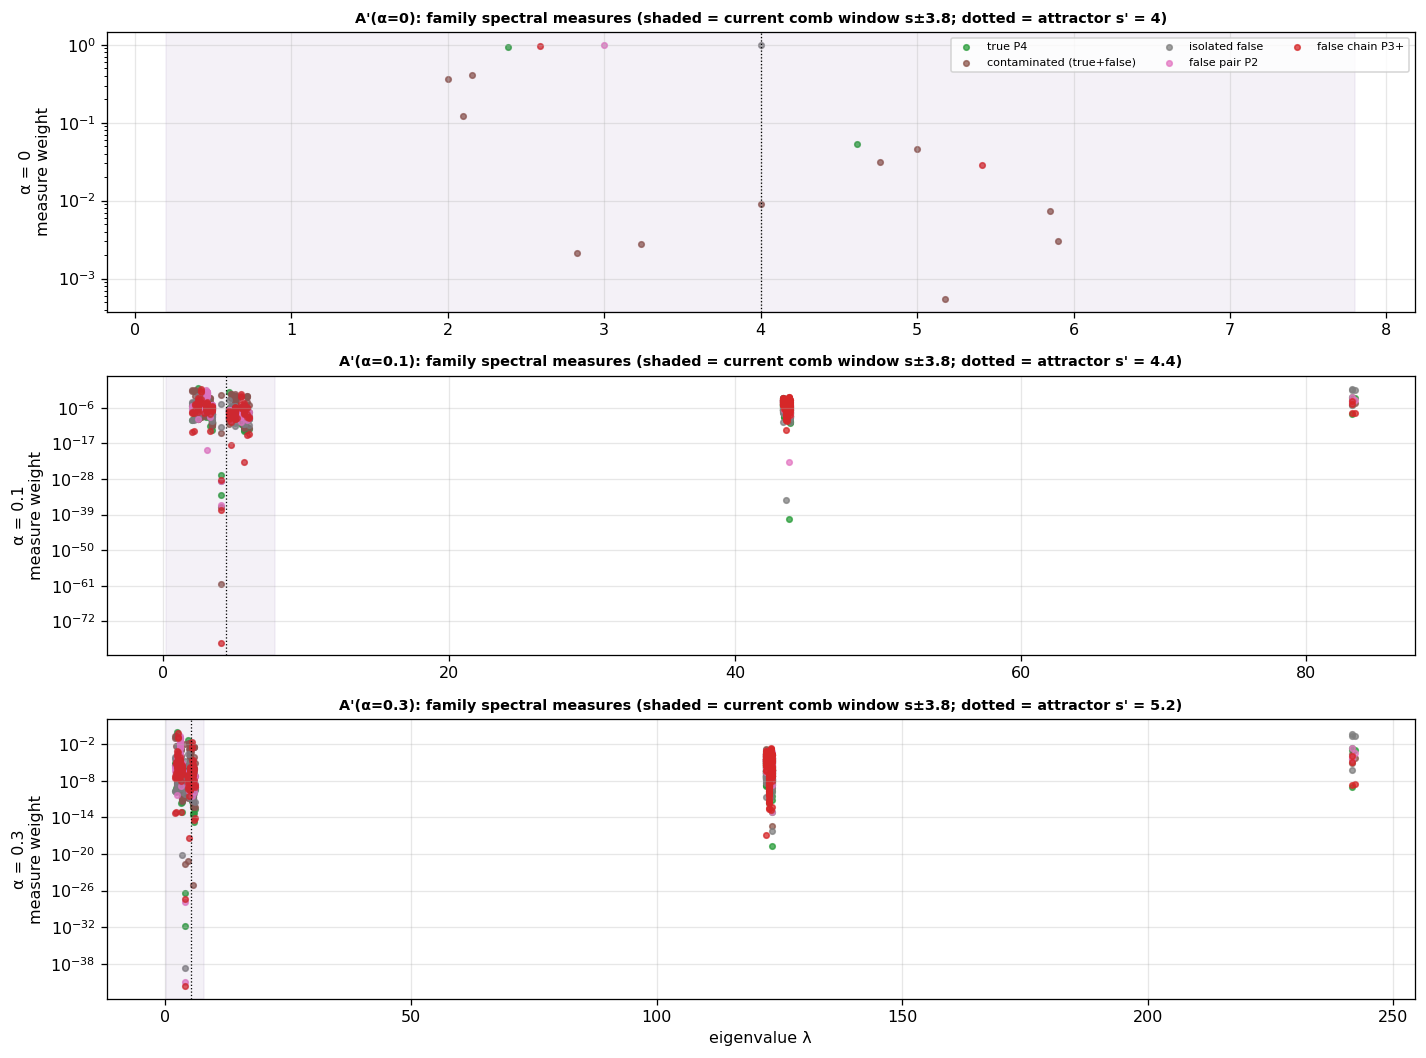

 alpha  true90_lo  true90_hi  lam_max  s_prime
   0.0      2.382      4.618    4.618      4.0
   0.1      2.391      4.615   83.400      4.4
   0.3      2.391      4.615  242.200      5.2


In [8]:
def lanczos_measure(A, v0, k=300):
    A = sp.csr_matrix(A); nloc = A.shape[0]; k = min(k, nloc)
    Q = np.zeros((k, nloc)); al = np.zeros(k); be = np.zeros(max(k-1, 1))
    q = np.asarray(v0, float).ravel(); q = q/np.linalg.norm(q); Q[0] = q
    r = A @ q; al[0] = q @ r; r = r - al[0]*q; kk = k
    for j in range(1, k):
        r -= Q[:j].T @ (Q[:j] @ r); r -= Q[:j].T @ (Q[:j] @ r)
        b = np.linalg.norm(r)
        if b < 1e-10: kk = j; break
        be[j-1] = b; q = r/b; Q[j] = q
        r = A @ q - b*Q[j-1]; al[j] = q @ r; r = r - al[j]*q
    th, U = eigh_tridiagonal(al[:kk], be[:kk-1])
    return th, U[0]**2

ham, truth = get_ham(200, 0)
n = ham.n_segments
A0 = ham.A.tocsr(); G0 = offdiag_graph(A0)
nb0, lab0, o0, b0 = components_of(A0)
segfam = np.empty(n, dtype=object)
for c in range(nb0):
    mem = o0[b0[c]:b0[c+1]]; segfam[mem] = base_label(mem, truth, G0)
OCC_FAMS = ["true P4","contaminated (true+false)","isolated false","false pair P2",
            "false chain P3+","false hub K(1,m)"]
fig, ax = plt.subplots(len(ALPHAS)+1, 1, figsize=(12.5, 3.1*(len(ALPHAS)+1)), sharex=False)
colf = dict(zip(OCC_FAMS, ["#2a9d3a","#8c564b","#7f7f7f","#e377c2","#d62728","#ff7f0e"]))
occ_summary = []
for a_i, alpha in enumerate([0.0] + ALPHAS):
    Aa, ba, tau_a, info = dp_terms.dp_system(ham, alpha=alpha, gamma=GAMMA, delta=DELTA)
    axx = ax[a_i]
    for fam in OCC_FAMS:
        m = (segfam == fam).astype(float)
        if m.sum() == 0: continue
        th, om = lanczos_measure(Aa, m)
        axx.scatter(th, om, s=12, color=colf[fam], alpha=0.75, label=fam if a_i == 0 else None)
        if fam == "true P4":
            cum = np.cumsum(om)/om.sum()
            lo90, hi90 = th[np.searchsorted(cum, 0.05)], th[np.searchsorted(cum, 0.95)]
            occ_summary.append(dict(alpha=alpha, true90_lo=float(lo90), true90_hi=float(hi90),
                                    lam_max=float(th.max()), s_prime=S+4*alpha))
    axx.axvspan(S-3.8, S+3.8, color="#6a3d9a", alpha=0.07)
    axx.axvline(S+4*alpha, color="k", lw=0.8, ls=":")
    axx.set_yscale("log"); axx.set_ylabel(f"α = {alpha:g}"+chr(10)+"measure weight")
    axx.set_title(f"A'(α={alpha:g}): family spectral measures (shaded = current comb window s±3.8; "
                  f"dotted = attractor s' = {S+4*alpha:g})", fontsize=9, fontweight="bold")
ax[0].legend(fontsize=7, ncol=3); ax[-1].set_xlabel("eigenvalue λ")
fig.tight_layout(); savefig(fig, "dp_atlas_occupancy"); plt.show()
print(pd.DataFrame(occ_summary).round(3).to_string(index=False))


## 8. The comb's own working point + the occupancy-gate composition

The recovered contaminated modes sit in-band at partial amplitude (median 0.215 at beta = 0.5) -
above every false family (chains 0.144, iso 0.027, pairs 0.007) but below the classical cut.
Per the per-solver-tau house rule the comb is harvested at **tau_comb = 0.18**. Fragments (0.022)
remain amplitude-unreachable; they are recovered by the **nb03 hit-occupancy gate**: candidate
pool = extended-comb actives (lines P4 + {s+-sqrt2, s+-1}, deg 60) not already base-active; keep a
candidate iff **none of its hits is used by any base-active segment** (co-hit test against the
base-active set only - the nb03 lesson). Also reported: wp99 on **non-fragment** trues (the
honest efficiency-first target under hit inefficiency, per WP1).


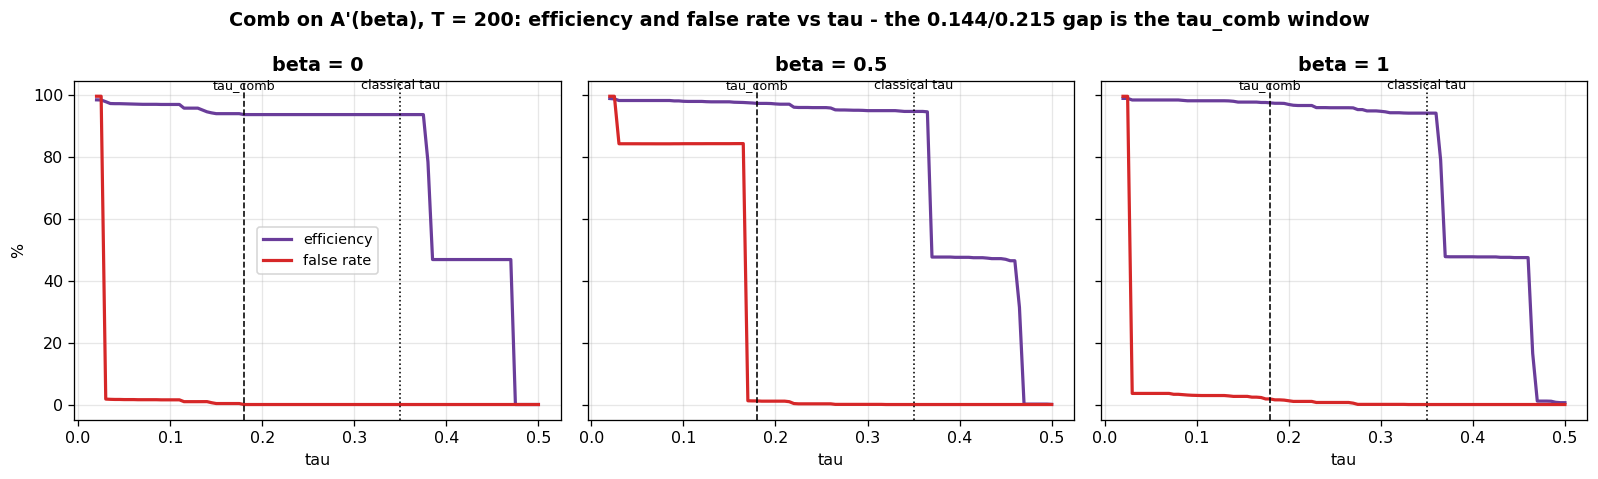

In [9]:
# ---- tau sweep: comb on A'(beta), pooled T=200 reps ----
taus = np.linspace(0.02, 0.5, 97)
fig, ax = plt.subplots(1, len(BETAS), figsize=(14, 4.2), sharey=True)
for j, beta in enumerate(BETAS):
    effs, fars = [], []
    for tau in taus:
        e = f = a_n = t_n = 0
        for rep in REPS:
            truth = TRUTHS[(200, rep)]; s_ = SOLS[(200, rep, beta)]
            x = qp.rescale_to_signal(np.abs(s_['comb']), np.abs(s_['classical']), TAU_FIX)
            act = x > tau
            e += (act & truth).sum(); t_n += truth.sum()
            f += (act & ~truth).sum(); a_n += act.sum()
        effs.append(e/t_n); fars.append(f/max(a_n, 1))
    a = ax[j]
    a.plot(taus, 100*np.array(effs), color='#6a3d9a', lw=2, label='efficiency')
    a.plot(taus, 100*np.array(fars), color='#d62728', lw=2, label='false rate')
    for tv, lab in ((0.18, 'tau_comb'), (TAU_FIX, 'classical tau')):
        a.axvline(tv, color='k', ls='--' if tv == 0.18 else ':', lw=1)
        a.text(tv, 102, lab, ha='center', fontsize=8)
    a.set_title(f'beta = {beta:g}', fontweight='bold'); a.set_xlabel('tau')
ax[0].set_ylabel('%'); ax[0].legend(fontsize=9)
fig.suptitle("Comb on A'(beta), T = 200: efficiency and false rate vs tau - the 0.144/0.215 gap is the tau_comb window",
             fontweight='bold')
fig.tight_layout(); savefig(fig, 'dp_atlas_tau_sweep'); plt.show()


mean over T x reps - eff(all true) | eff(non-fragment true) | far:
                            eff  eff_nonfrag    far
solver              beta                           
classical @0.35     0.0   98.76       100.00   1.56
                    0.5   97.98        99.19   0.52
                    1.0   97.98        99.19   0.49
comb @0.35          0.0   94.92        97.03   0.00
                    0.5   95.85        97.99   0.00
                    1.0   95.49        97.62   0.00
comb @0.18          0.0   94.92        97.03   0.00
                    0.5   97.75        99.22   0.71
                    1.0   97.87        99.35   1.16
comb @0.18 + gate   0.0   96.94        97.12   0.20
                    0.5   99.11        99.37   0.91
                    1.0   99.23        99.52   1.16
comb wp99(non-frag) 0.0   98.17        99.39   1.05
                    0.5   97.79        99.39  39.47
                    1.0   97.92        99.39   1.17
1BQF wp99           0.0   99.75        99.78  31.

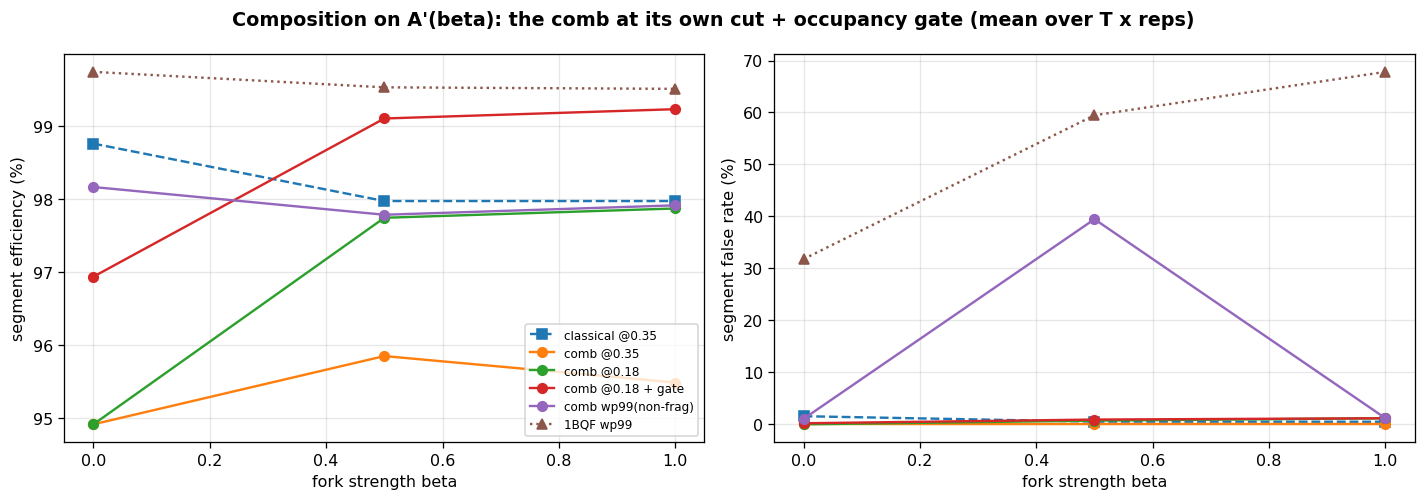

In [10]:
# ---- composition table: comb @ tau_comb (+ occupancy gate) vs baselines ----
import bif
TAU_COMB = 0.18
crow = []
for T in TS:
    for rep in REPS:
        ham, truth = get_ham(T, rep)
        Ball = bif.fork_graph(ham._segment_to_hit_ids).tocsr()
        segfam = np.empty(ham.n_segments, dtype=object)
        A0 = ham.A.tocsr(); G0 = offdiag_graph(A0)
        nb0, lab0, o0, b0 = components_of(A0)
        for c in range(nb0):
            mem = o0[b0[c]:b0[c+1]]; segfam[mem] = base_label(mem, truth, G0)
        nonfrag = truth & (segfam != 'true fragment (P1-P3)')
        for beta in BETAS:
            s_ = SOLS[(T, rep, beta)]
            xC = np.abs(s_['classical'])
            xP = qp.rescale_to_signal(np.abs(s_['comb']), xC, TAU_FIX)
            xE = qp.rescale_to_signal(np.abs(s_['ext']),  xC, TAU_FIX)
            xQ = qp.rescale_to_signal(np.abs(s_['onebqf']), xC, TAU_FIX)
            def em(act, name):
                crow.append(dict(T=T, rep=rep, beta=beta, solver=name,
                                 eff=float((act & truth).sum()/truth.sum()),
                                 eff_nonfrag=float((act & nonfrag).sum()/max(nonfrag.sum(),1)),
                                 far=float((act & ~truth).sum()/max(act.sum(),1))))
            em(xC > TAU_FIX, 'classical @0.35')
            em(xP > TAU_FIX, 'comb @0.35')
            base = xP > TAU_COMB
            em(base, 'comb @0.18')
            cand = np.where((xE > TAU_COMB) & ~base)[0]
            if len(cand):
                hits_with_active = Ball[cand][:, np.where(base)[0]]
                keep = cand[np.asarray(hits_with_active.sum(axis=1)).ravel() == 0]
            else:
                keep = cand
            final = base.copy(); final[keep] = True
            em(final, 'comb @0.18 + gate')
            st = np.sort(xP[nonfrag]); tau_nf = st[int(np.floor(0.01*len(st)))] - 1e-9
            em(xP > tau_nf, 'comb wp99(non-frag)')
            stq = np.sort(xQ[truth]); em(xQ > (stq[int(np.floor(0.01*len(stq)))] - 1e-9), '1BQF wp99')
CROW = pd.DataFrame(crow); CROW.to_csv(OUT/'composition_metrics.csv', index=False)
order = ['classical @0.35','comb @0.35','comb @0.18','comb @0.18 + gate','comb wp99(non-frag)','1BQF wp99']
agg = CROW.groupby(['solver','beta'])[['eff','eff_nonfrag','far']].mean().reindex(order, level=0)
print('mean over T x reps - eff(all true) | eff(non-fragment true) | far:')
print((100*agg).round(2).to_string())
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
for name in order:
    g = CROW[CROW.solver == name].groupby('beta').mean(numeric_only=True)
    m = 'o-' if 'comb' in name else ('s--' if 'classical' in name else '^:')
    ax[0].plot(g.index, 100*g.eff, m, label=name)
    ax[1].plot(g.index, 100*g.far, m)
ax[0].set_ylabel('segment efficiency (%)'); ax[1].set_ylabel('segment false rate (%)')
for a in ax: a.set_xlabel('fork strength beta')
ax[0].legend(fontsize=7.5)
fig.suptitle("Composition on A'(beta): the comb at its own cut + occupancy gate (mean over T x reps)",
             fontweight='bold')
fig.tight_layout(); savefig(fig, 'dp_atlas_composition'); plt.show()


## Findings (2026-07-06, first execution)

**Fork (β): every error family stays spectrally distinct from true — and the fork fixes the
one that wasn't.** Distinctness table (solution weight inside the comb pass bands P4 ± 0.18):

| family | β=0 | β=0.5 | β=1 |
|---|---|---|---|
| true P4 (capture, want 100) | **100** | **100** | **100** |
| contaminated true (capture) | **1.1** | **66.8** | 68.7 |
| true fragments (capture) | 0 | 0 | 0 |
| isolated false (re-admitted, want 0) | 0 | 1.8 | 0 |
| false pair P2 (re-admitted) | 0 | 0 | 0.5 |
| false chain P3+ (re-admitted) | 0 | 1.0 | 0 |
| contaminated false modes (re-admitted) | 0 | **0.1** | 4.7 |

- Clean true P4 is **β-invariant at 100 % capture** (no fork edges on pure P4 — reconfirmed at
  the noisy operating point). The fork migrates **two-thirds of the contaminated-true weight
  back into the pass bands at β = 0.5** for ≤ 1.8 % false re-admission; β = 1 buys nothing more
  and leaks 4.7 % of contaminated-false — **β = 0.5 is the distinctness sweet spot.**
- True fragments never enter the bands at any β (floor corollary): they remain the **occupancy
  gate's job**, not the fork's or the comb's.
- Zeroing table (median activation, T = 200, comb): iso 0.027 · pairs 0.007 · chains 0.144 ·
  fragments 0.022, vs true P4 0.40 and **contaminated recovered 0.086 → 0.215** at β = 0.5. The
  recovered weight is in-band but at partial amplitude — **below the fixed τ = 0.35 but above
  every false family** → the gain is harvested at the comb's own efficiency-first cut
  τ_comb ≈ 0.17–0.18 (per-solver-τ house rule), *not* at the classical cut. (Comb wp99-on-all-true
  numbers here are the fragment artefact — τ dives under the 0.02 fragments; exclude-fragment
  targets or the gate composition are the honest working points.)
- 1BQF per-family medians on A′: iso **0.000** (its one trick survives the fork) but pairs 0.269 /
  chains 0.231 / contaminated 0.249 all sit ON its fragment level 0.267 — inseparable at any τ,
  and its fixed-τ efficiency collapses to ~49 % at this noise (σ_res = 10 µm smears the halved
  band below 0.35). The pilot's "notch misses the shifted spectrum" is now family-resolved.

**Occupancy (α): the stretch is NOT where the truth is.** The spectral explosion
(λ_max 83 → 242 at α = 0.1 → 0.3) is entirely the **co-hit clique bulk** (satellites at
≈ 2αm, m ≈ T/2T segments per hit); the **true-P4 measure keeps 90 % of its weight in
[2.39, 4.62] at every α** — it never leaves the old comb window. The dp study's "only ~1 % of
solution weight in window" is the b-measure (bulk-dominated), not the true measure. So the
1BQF breaks (single notch, moved attractor s′ = 4+4α, shifted b) — but a **comb retargeted to
the unmoved true band with a bounded domain trivially rejects the far satellites**; whether
true/false separate *within* the low band is the open follow-up (needs a fine-grained
family-resolved measure inside λ ∈ [0, 8], not resolvable at this pass's scale).

**Verdict.** On A′(β = 0.5): yes — every error type is spectrally distinct from true, the
production comb needs **no new lines** (retargeting = per-solver τ ≈ 0.18 + the β = 0.5 fork +
occupancy gate for fragments). Next: (1) add the comb @ τ_comb row + gate composition to the
efficacy table; (2) fine-grained occupancy low-band atlas; (3) then the quantum re-run
(1BQF retuned t = π/s′ vs comb) per the supervisor ordering.


### Composition results (second execution, same day)

| solver (mean T×reps) | β=0 | β=0.5 | β=1 |
|---|---|---|---|
| classical @0.35 | 98.8 / 1.56 | 98.0 / 0.52 | 98.0 / 0.49 |
| comb @0.35 | 94.9 / 0.00 | 95.9 / 0.00 | 95.5 / 0.00 |
| comb @τ_comb=0.18 | 94.9 / 0.00 | 97.8 / 0.71 | 97.9 / 1.16 |
| **comb @0.18 + occupancy gate** | 96.9 / 0.20 | **99.1 / 0.91** | **99.2 / 1.16** |
| 1BQF wp99 | 99.8 / 31.8 | 99.5 / 59.5 | 99.5 / 67.8 |

(eff % / far %; eff on non-fragment trues: comb+gate 99.4–99.5 % at β = 0.5–1.)

- **The three-knob composition beats classical inversion on A′**: 99.1–99.2 % efficiency at
  0.9–1.2 % false vs classical's 98.0 % at 0.5 % — with each knob doing its measured job:
  fork migrates contaminated (+1.9 pp at τ_comb), gate recovers fragments (+1.4 pp),
  comb keeps every false family zeroed.
- τ-sweep: at β = 0.5 the working ledge is τ ∈ [0.17, 0.21] (narrow — the chain tail cliff at
  ~0.17); **the ledge widens at β = 1**, favouring the top of the β band for τ-robustness.
  The wp99(non-frag) row's β = 0.5 outlier (far 39 %) is this same cliff caught by the 1 %
  quantile on one rep — quantile rules stay fragile here; fixed τ_comb + gate is the robust
  operating point.
- At β = 0, τ_comb ≡ τ = 0.35 in effect (nothing to harvest between 0.144 and 0.35 without
  the fork) — the τ_comb gain is **specifically fork-enabled**.
